## Proyecto Sprint 13

El objetivo de este análisis es entrenar un modelo de machine learning de regresión logística y bosque aleatorio para predicir la probabilidad de perdida de los clientes de la cadena de gimnasios Model Fitness para el siguiente mes. También se elaborarán clusters de los grupos de clientes mediante el algoritmo K-means para identificar qué grupos son más propensos en irse y cuales más leales. 
Para cada modelo se analizarán las metricas correspondientes para poder identificar cual se ajusta más al caso de análisis.  
También se estudiarán la relación entre las características y la importancia de cada usa sobre la decisión de un cliente para cancelar la suscripción y de esa menera realizar recomendaciones sobre como reducir la rotación de clientes y brindar un mejor servicio.     

### 1. Análisis Exploratorio de Datos 

In [32]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import dendrogram, linkage 

In [33]:
#importación de los datos 
gym = pd.read_csv('gym_churn_us.csv')
gym.head()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,0


In [34]:
#se analiza informacion general de los datos 
gym.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 14 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   gender                             4000 non-null   int64  
 1   Near_Location                      4000 non-null   int64  
 2   Partner                            4000 non-null   int64  
 3   Promo_friends                      4000 non-null   int64  
 4   Phone                              4000 non-null   int64  
 5   Contract_period                    4000 non-null   int64  
 6   Group_visits                       4000 non-null   int64  
 7   Age                                4000 non-null   int64  
 8   Avg_additional_charges_total       4000 non-null   float64
 9   Month_to_end_contract              4000 non-null   float64
 10  Lifetime                           4000 non-null   int64  
 11  Avg_class_frequency_total          4000 non-null   float

No se presentan valore ausentes ni caracteristicas cualitativas por lo que no se requiere procesamiento en este caso. 

In [35]:
#se analiza las estadísticas generales 
gym.describe()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
count,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000,4000.000000
mean,0.510250,0.845250,0.486750,0.308500,0.903500,4.681250,0.412250,29.184250,146.943728,4.322750,3.724750,1.879020,1.767052,0.265250
std,0.499957,0.361711,0.499887,0.461932,0.295313,4.549706,0.492301,3.258367,96.355602,4.191297,3.749267,0.972245,1.052906,0.441521
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,18.000000,0.148205,1.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,27.000000,68.868830,1.000000,1.000000,1.180875,0.963003,0.000000
50%,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000,29.000000,136.220159,1.000000,3.000000,1.832768,1.719574,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,6.000000,1.000000,31.000000,210.949625,6.000000,5.000000,2.536078,2.510336,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,1.000000,41.000000,552.590740,12.000000,31.000000,6.023668,6.146783,1.000000


In [36]:
#se analiza los valores medios de características para los grupos 
gym_groups = gym.groupby('Churn').mean()
gym_groups

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month
Churn,,,,,,,,,,,,,
0,0.510037,0.873086,0.534195,0.353522,0.903709,5.747193,0.464103,29.976523,158.445715,5.283089,4.711807,2.024876,2.027882
1,0.510839,0.768143,0.355325,0.183789,0.902922,1.728558,0.268615,26.989632,115.082899,1.662582,0.990575,1.474995,1.044546


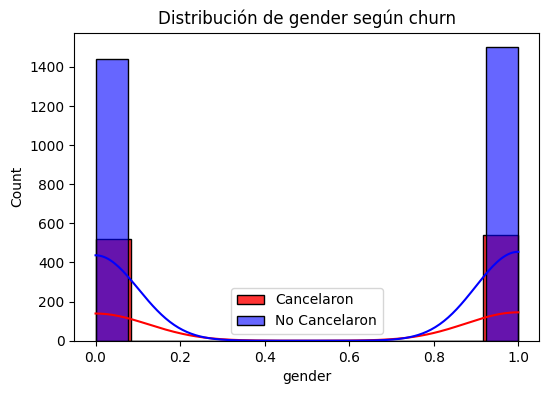

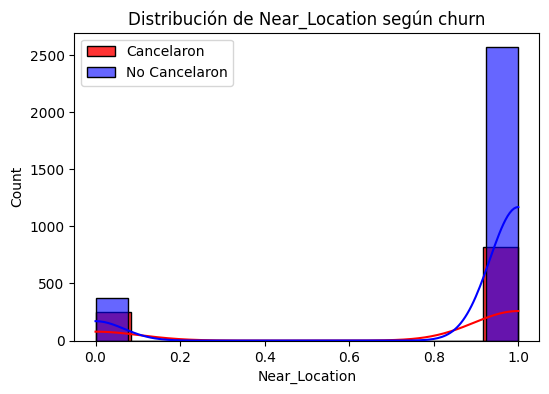

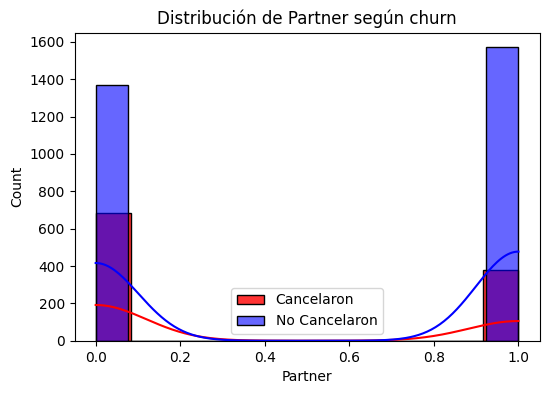

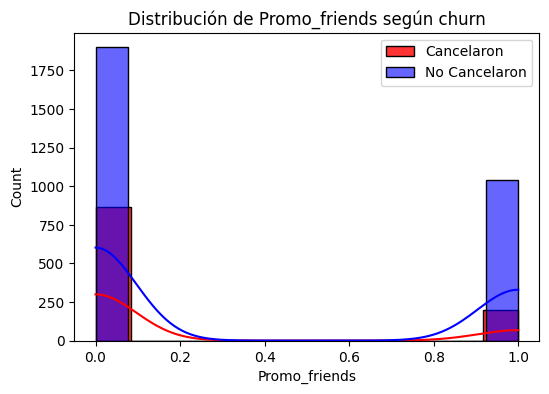

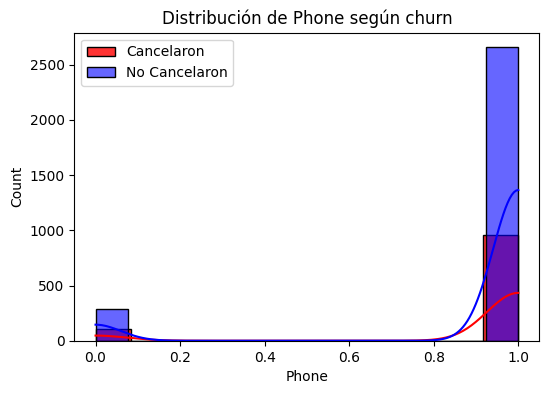

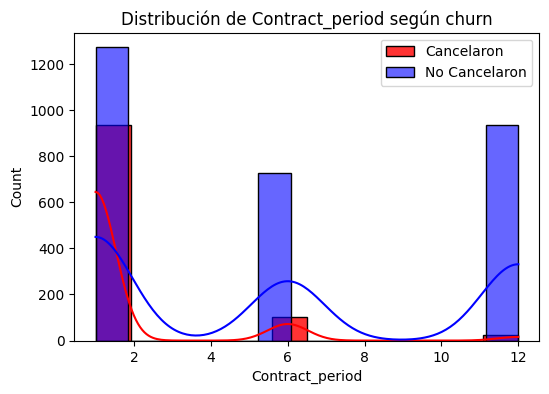

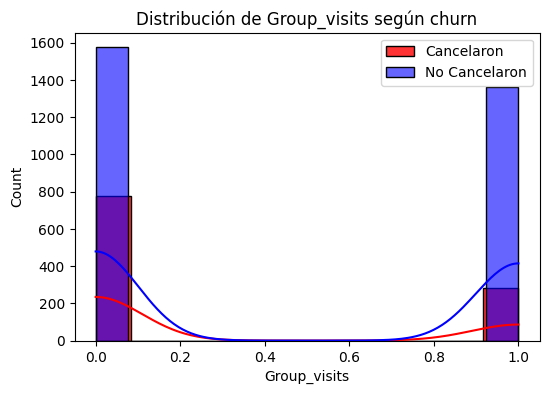

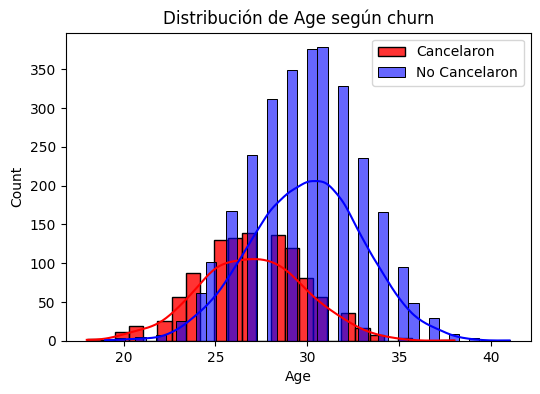

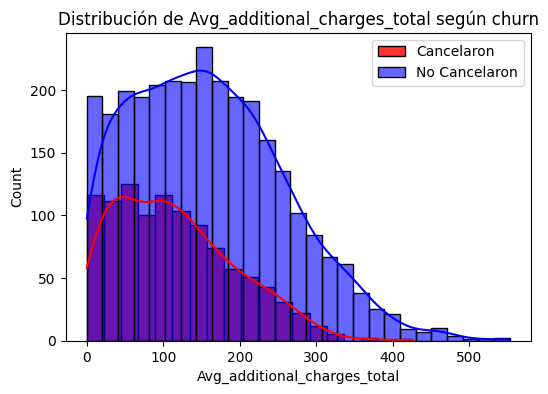

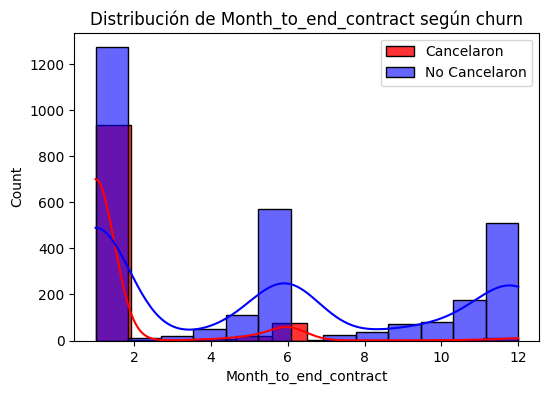

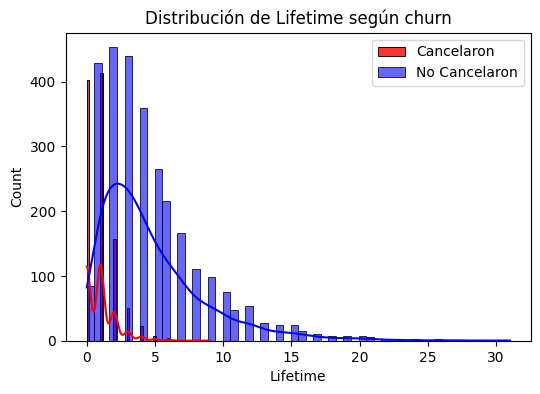

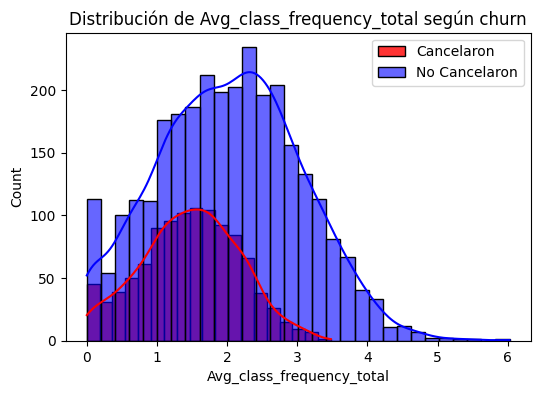

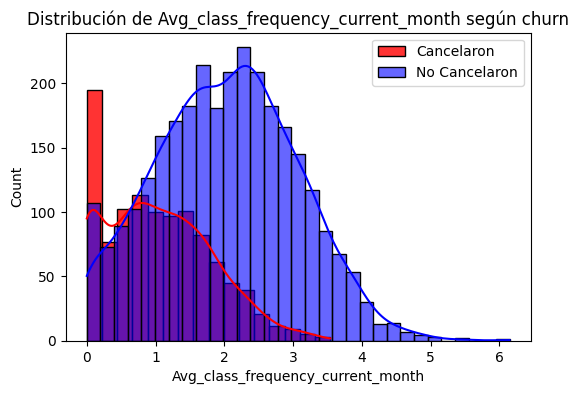

In [37]:
#se realizan gráficos de histograma y distribución de características para los grupos 
churn1 = gym[gym['Churn'] == 1]
churn0 = gym[gym['Churn'] == 0]

for col in gym.columns: 
    if col != 'Churn': 
        plt.figure (figsize= (6,4))

        sns.histplot(churn1[col], kde = True, color = 'red', label = 'Cancelaron', alpha = 0.8)

        sns.histplot(churn0[col], kde = True, color = 'blue', label = 'No Cancelaron', alpha = 0.6)

        plt.title (f'Distribución de {col} según churn')
        plt.legend()
        plt.show()




- La observación proncipal es que en todos los gráficos, la mayor cantidad de clientes del gimnasio no han cancelado su suscripción, lo cual es una gran señal para el negocio. 
- Por lo general los que cancelan con los de menor edad y los que contratan el servicio por pocos meses de entrada. 
- También se puede ver que la mayoría de los que cancelarion no tomaron clases grupales y asistían pocas veces a la semana al gimnasio. Se podría pensar que al ir por su cuenta, no se sentían motivados en seguir asistiendo en el gimnasio o que no tenían un conocimiento de los ejercicios que podrían hacer o como hacerlos y por eso decidieron salirse. 

<Axes: >

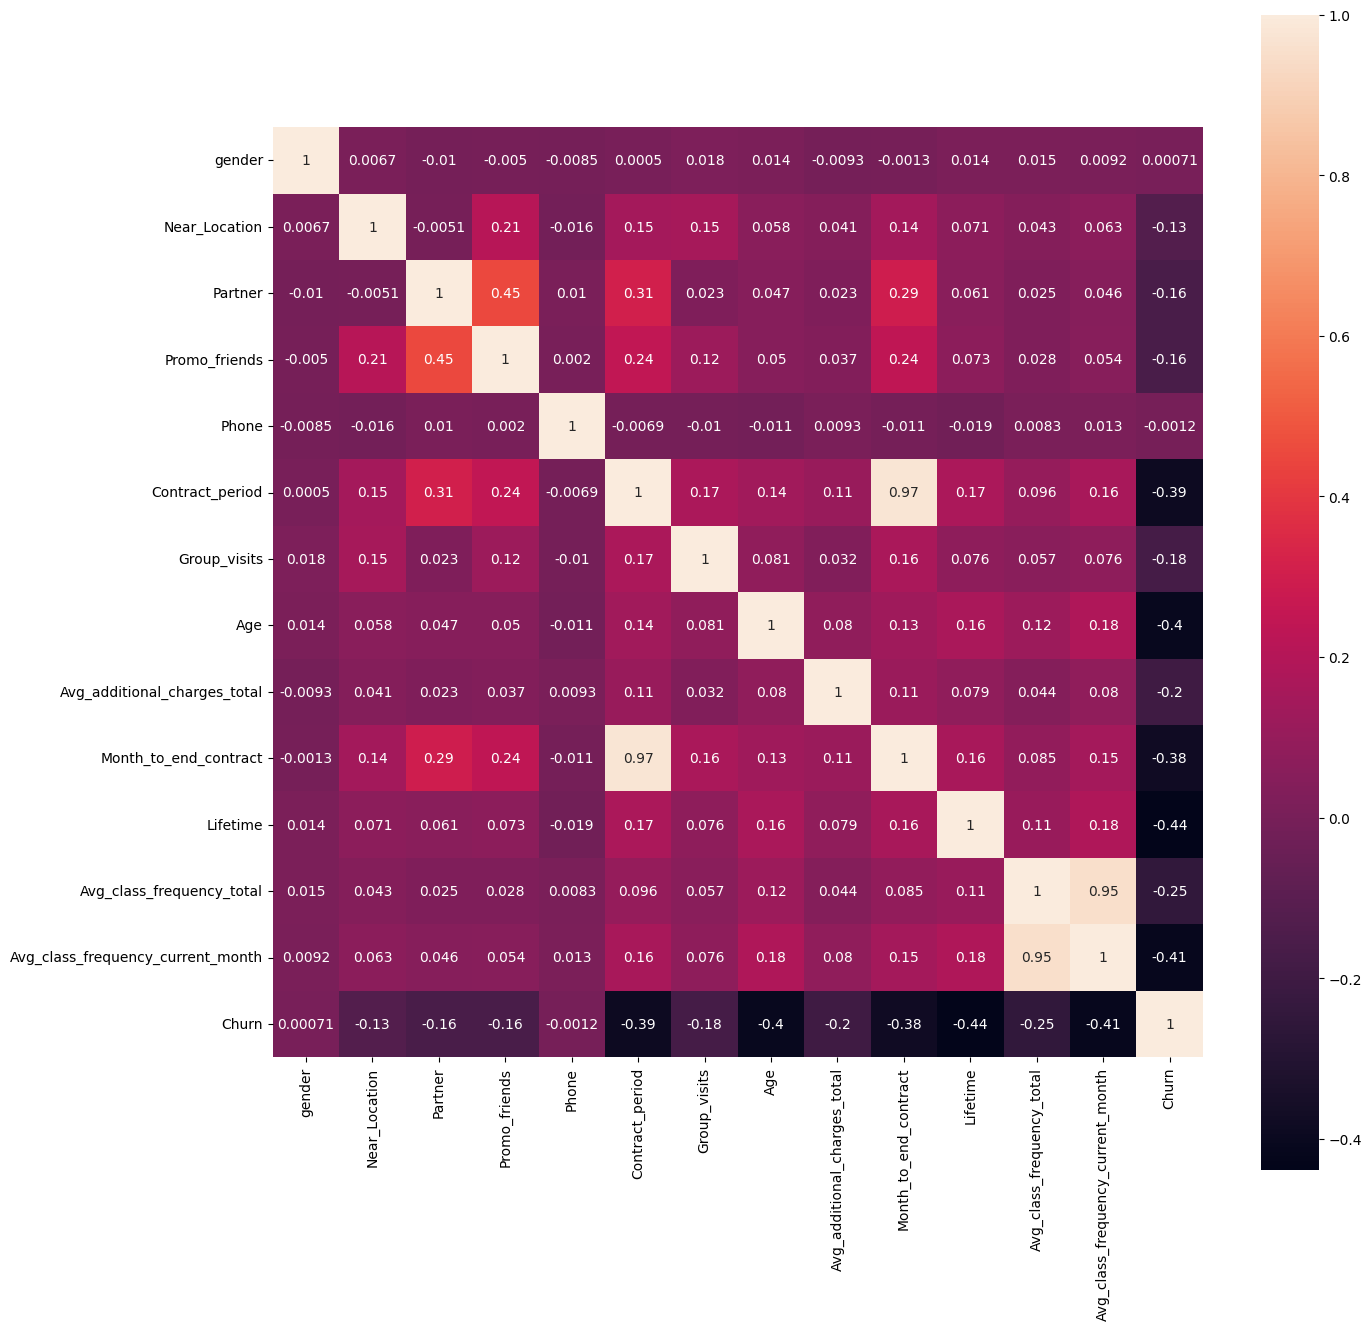

In [38]:
#se crea una matriz de correlación y un heatmap para mostrarla 
corr = gym.corr()

plt.figure (figsize= (15,15))
sns.heatmap(corr, annot = True, square = True)

No se encuentra ninguna correlación fuerte entre la variable objetivo Churn y las características presentadas, por lo que se debe realizar un modelo y así identificar que características son más importantes para la toma de decisiones de los clientes. 

### 2. Construir un modelo para predecir la cancelación de usuarios 

Se van a contruir 2 modelos de clasificación binaria: Regresión logística y Bosque aleatoreo y mediante las métricas se identificará cual es mejor para la predicción de cancelación de usuarios. 

In [39]:
#se divide los datos en variable obetivo y características. 
X = gym.drop ('Churn', axis = 1)
y = gym ['Churn']

In [40]:
#se divide los datos en conjunto de entrenamiento y prueba 
X_train, X_test, y_train, y_test = train_test_split (X, y, test_size= 0.2, random_state= 0)

In [41]:
#estandarización de los datos 
scaler = StandardScaler()
X_train_st = scaler.fit_transform(X_train)
X_test_st = scaler.transform(X_test)

In [42]:
#Se define la función para imprimir métricas
def metrics (y_true, y_pred, title = 'Métricas de Clasificación'): 
    print (title)
    print ('\tExactitud: {:.2f}'.format(accuracy_score(y_true, y_pred)))
    print ('\tPrecisión: {:.2f}'.format(precision_score(y_true, y_pred)))
    print ('\tRecall: {:.2f}'.format(recall_score(y_true, y_pred)))
    print ('\tF1: {:.2f}'.format(f1_score(y_true, y_pred)))

In [43]:
#algoritmo para regresión logísitica 
lg_model = LogisticRegression(random_state= 0)
lg_model.fit(X_train_st, y_train)
y_pred_lg = lg_model.predict (X_test_st)
metrics(y_test, y_pred_lg, title = 'Metricas Regresión Logísitca')

#algoritmo para bosque aleatorio
rf_model = RandomForestClassifier(random_state= 0)
rf_model.fit(X_train_st, y_train)
y_pred_rf = rf_model.predict (X_test_st)
metrics(y_test, y_pred_rf, title = 'Metricas Bosque Aleatorio')

Metricas Regresión Logísitca
	Exactitud: 0.92
	Precisión: 0.85
	Recall: 0.83
	F1: 0.84
Metricas Bosque Aleatorio
	Exactitud: 0.92
	Precisión: 0.84
	Recall: 0.81
	F1: 0.83


Al analizar las métricas de ambos modelos, se puede ver que los modelos se ajustan de manera muy similar al caso de análisis. Se puede decir que el modelo de regresión logística es más preciso por la pequeña diferencia que existe entre las métrocas de precisión, recall y F1. 

### 3. Crear clusters de usuaria/os 

In [44]:
# se estandarizan los datos y se crea la matriz de distancia  
sc = StandardScaler()
X_sc = sc.fit_transform(X)
distancia = linkage(X_sc, method='ward')

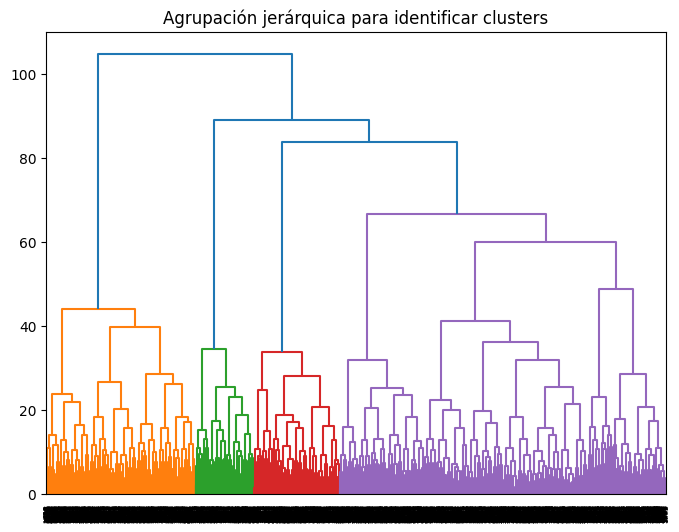

In [45]:
#se crea el dendrograma 
plt.figure (figsize= (8,6))
dendrogram(distancia, orientation='top')
plt.title ('Agrupación jerárquica para identificar clusters')
plt.show()

Según el dendrograma realizado, el número de clusters que se deberían tomar en cuenta para el algoritmo k-mean es de 4.

In [62]:
#Se entrena el modelo kmeans con 5 clusters sugueridos en indicación del proyecto. 
km = KMeans(n_clusters=5, random_state=0)
labels = km.fit_predict(X_sc)

In [63]:
#se almacena las etiquedas de clusters al conjunto de datos X
X['cluster_km'] = labels 
X.head()

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,cluster_km
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,3
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,2
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,2
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,3


In [64]:
#se calcula los valores medios de características por clusters 
mean = X.groupby('cluster_km').mean()
mean 

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month
cluster_km,,,,,,,,,,,,,
0,0.486819,1.000000,0.243409,0.007030,0.899824,1.978910,0.326889,28.239016,130.877033,1.896309,2.477153,1.318003,1.083831
1,0.592493,0.970509,0.288204,0.123324,0.898123,2.898123,0.482574,30.339142,164.193829,2.654155,5.219839,2.937411,2.944131
2,0.499469,0.943677,0.740701,0.489904,0.900106,11.866100,0.551541,29.905420,165.146492,10.852285,4.737513,1.989423,1.980764
3,0.483360,1.000000,0.798732,1.000000,0.911252,3.079239,0.445325,29.052298,139.858265,2.873217,3.510301,1.665722,1.547717
4,0.496324,0.000000,0.466912,0.077206,0.915441,2.209559,0.215074,28.483456,133.630215,2.073529,2.781250,1.657657,1.466870


Las principales obervaciones que se pueden ver: 
- todos los grupos son balanceados en cuanto al género, a excepción del grupo 1 que tienen una pequeña inclinación hacia Hombres.
- el grupo 0 y 3 se encuentran cerca del gimnasio, sin embargo los integrantes del grupo 0 prácticamente no se han incrito mediante promoción de amigos, a diferencia del grupo 1 que todos se incribieron con esta promoción y gran parte de ellos se han inscrito bajo la promoción por trabajar en compañía asociada. 
- el grupo 2 es el que en promedio mayor tiempo de contratos generan con una media de casi 12 meses, en su mayoría viven cerca del gimanasio, son los que más gastan en cargos adicionales, . 
- el grupo 1 muy similar al grupo 2, a diferencia que el contrato primedo esta cerca de los 3 meses y son lo de mayor edad con 30 años. Son los que más tiempo han estado en el gimnasio desde su primera inscripción y son los que más veces a la semana asisten a clases. 
- el grupo 4 es el único en el que todos los integrantes están lejos del gimnasio, en su mayoría no se incriben con una promoción de amigos y hacen una contratación de servicios promedio de 2 meses. 

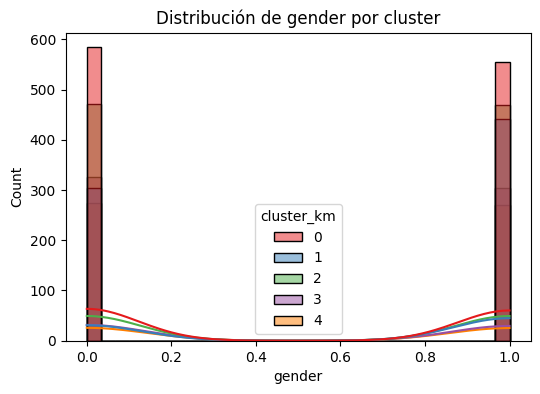

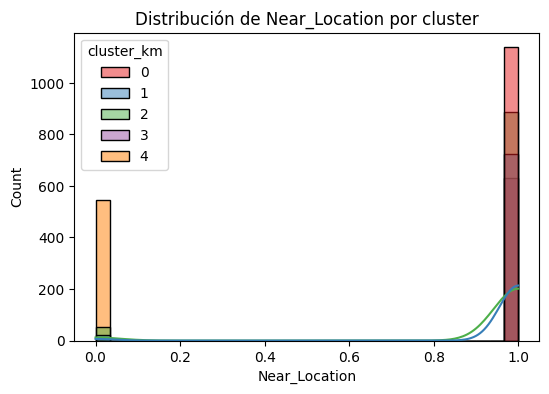

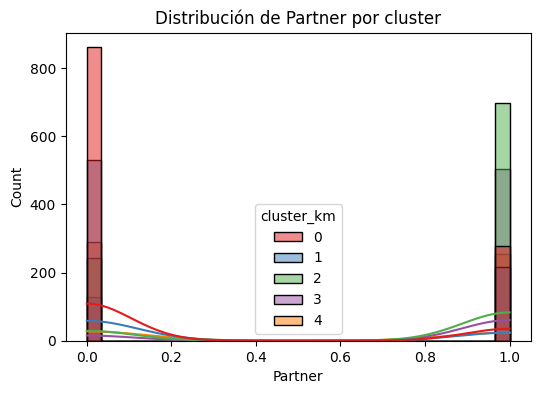

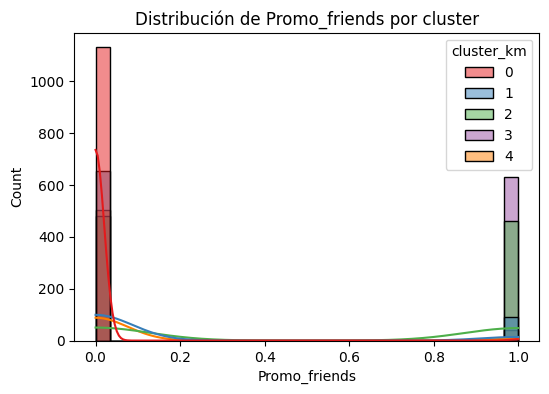

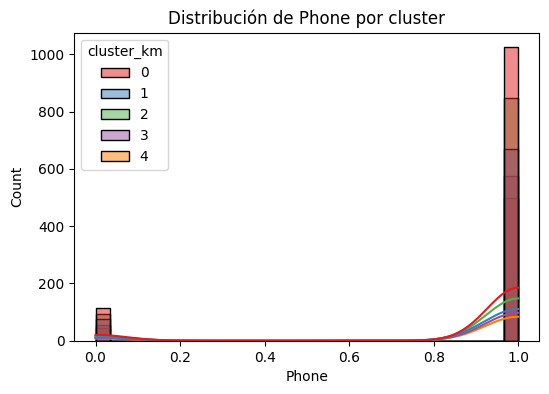

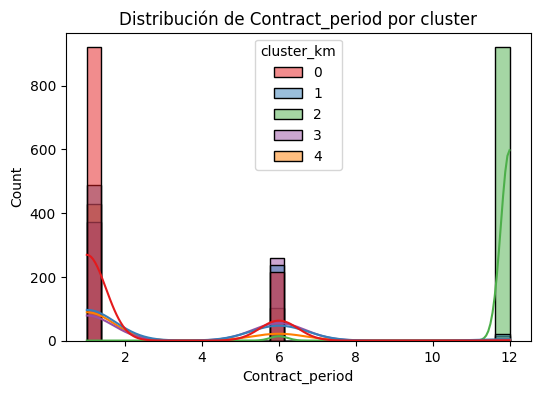

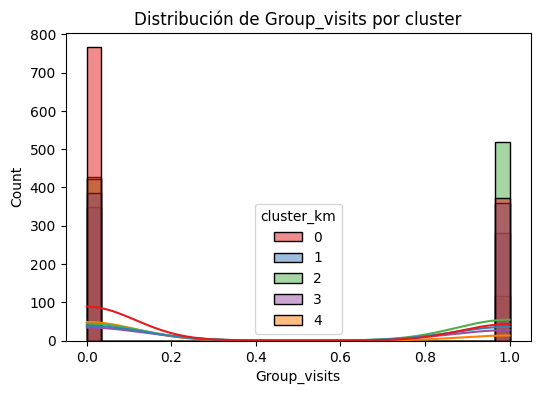

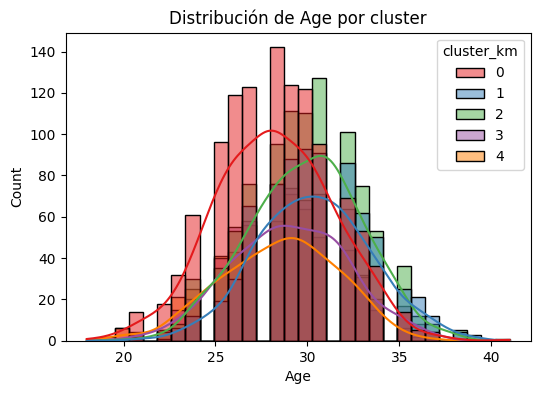

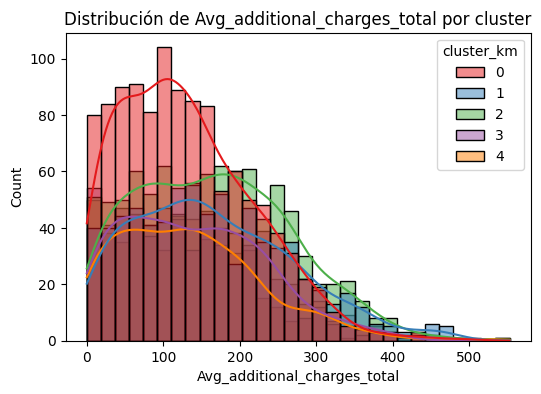

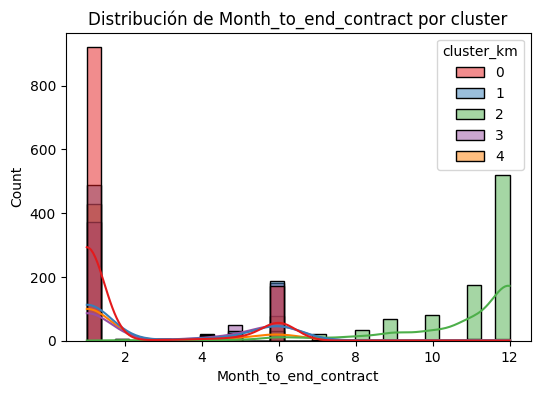

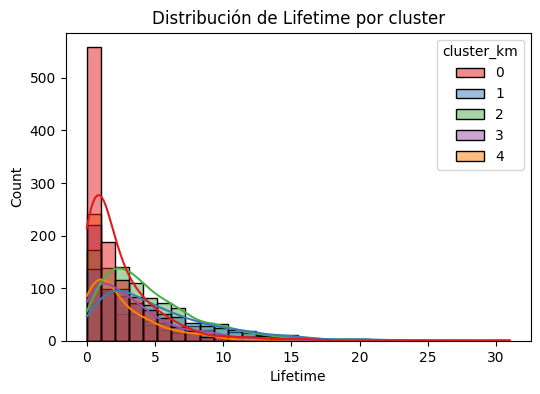

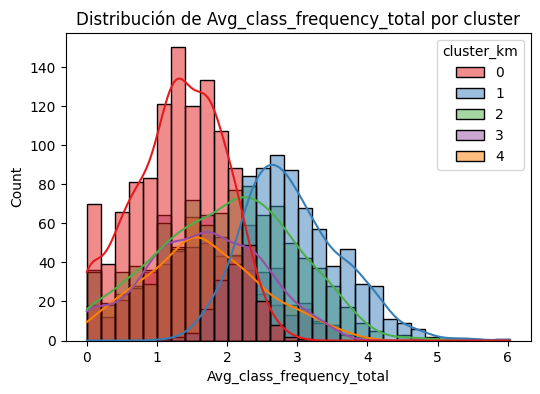

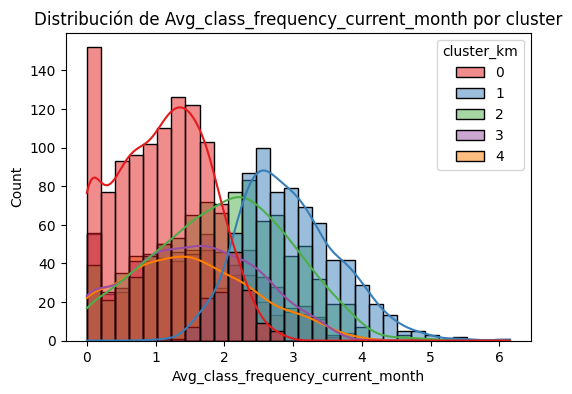

In [66]:
#se realizan gráficos de distribución de características para los clusters
for col in X.drop (columns = ['cluster_km']).columns: 
        plt.figure (figsize= (6,4))
        sns.histplot(X, x=col, hue='cluster_km', kde = True, bins=30, palette='Set1')
        plt.title (f'Distribución de {col} por cluster')
        plt.show()

- Al analizar los gráficos, se puede decir que el grupo 0 es el que mayor cantidad de clientes contiene ,seguido del grupo 2. 
- Los grupos que asisten a la mayor cantidad de clases al mes son el grupo 1 y 2, mientras que el grupo 0 a pesar de ser el que mayor cantidad de clientes tiene, son los que a menos clases asisten, esto puede ser por la edad de los clientes ya que se puede ver en el gráfico de edad que contienen a las menores edaddes. Paracería que los clientes del grupo 0 son relativamente nuevos ya que el ciclo de vida que han tenido es muy corto. 

In [67]:
#se agrega la columna Churn al dataframe X para calcular tasa de cancelación  
X['churn'] = gym['Churn']
X

,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,cluster_km,churn
0,1,1,1,1,0,6,1,29,14.227470,5.0,3,0.020398,0.000000,3,0
1,0,1,0,0,1,12,1,31,113.202938,12.0,7,1.922936,1.910244,2,0
2,0,1,1,0,1,1,0,28,129.448479,1.0,2,1.859098,1.736502,0,0
3,0,1,1,1,1,12,1,33,62.669863,12.0,2,3.205633,3.357215,2,0
4,1,1,1,1,1,1,0,26,198.362265,1.0,3,1.113884,1.120078,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,1,1,1,0,1,12,0,33,2.406023,12.0,8,2.284497,2.349070,2,0
3996,0,1,0,0,1,1,1,29,68.883764,1.0,1,1.277168,0.292859,0,1
3997,1,1,1,1,1,12,0,28,78.250542,11.0,2,2.786146,2.831439,2,0
3998,0,1,1,1,1,6,0,32,61.912657,5.0,3,1.630108,1.596237,3,0


In [72]:
#se calcula la tasa de cancelación para cada cluster.
tasa_cancelacion = X.groupby('cluster_km')['churn'].mean().reset_index()
tasa_cancelacion.columns = ['Cluster', 'Tasa de cancelación']
tasa_cancelacion

,Cluster,Tasa de cancelación
0,0,0.513181
1,1,0.054960
2,2,0.022317
3,3,0.269414
4,4,0.450368


- Al calcular la tasa de cancelación, se puede ver que los grupos más propensos a irse con más del 50% en el grupo 0 y con 45% el grupo 4. 
- El grupo 1 y 2 son los que menos probabilidad tienen de irse siendo los más leales. 
- El grupo 3 tiene una tasa de cancelación de 27%. en este caso 27% podría ser considerado como una tasa significativa para el gimnasio. 

### 4. Recomendaciones 

- Al analizar las tasas de cancelación para cada grupo y las distribuciones de cada uno, se puede decir que el grupo más rentable y leal es el grupo 2. Estos clientes son los que optan por un contrato de mayor tiempo y son los más leales, lo que tiene relación entre si. 
- Adicionalmente el grupo 2 tienen una gran cantidad de clientes que provienen de empresas que tienen convenio con el gimasio, por que al tener un descuento optan por un contrato de servicio más largo. Se podrían generan más convenios con otras empresas que se encuentran cercanas al gimnasio para así atraer más clientes con características similares. Además que son los que más gastan en servicios adicionales, lo cual también tiene relación con que son personas con ingresos fijos y pueden darse más gustos. 
- Se debe considerar al grupo 0, este es el que mayor cantidad de clientes tiene y el grupo que tiene la tasa de cancelación más alta también. Como se analizaba anteriormente, es importante tratar de retener más a estos clientes ya que son gran parte de los clientes del gimnasio pero al ver que son los de menor edad, se podría ofrecer: 
    1. descuento por estudiantes en membresias de 3 meses en adelante, así se los puede retener por un mayor tiempo. 
    2. al ver que este grupo tiene poca participación en clases grupales, puede ser porque son estudiantes y van a la hora que tengan tiempo, se podría considerar la opción de ofrecer entrenadores en el área de gimnasio abierto que te puedan guiar y armar un entrenamiento para los días que vas sin costo adicional. De esta manera, los jóvenes  podrían tener un impúlso y motivación extra al momeno de ir a entrenar y no sentirse desganados por no saber que hacer. 
- También se podría sectorizar la publicidad hacia áreas más cercanas para atraer más clientes ya que estos grupos (1,2,3) son lo que menot tasa de cancelación tienen. La gente prefiere ir a un gimasio que se encuentre cerca a su trabajo o residencia y ahorrar tiempo en este caso. 
- Esto se puede evidenciar con el grupo 4, el cual todos los clientes no viven o trabajan cerca del gimnasio y su tasa de cancelación es de casi el 50%. En este caso, se podría ofrecer un descuento para este grupo de clientes al momento de renovar su suscripción. 
- Como recomendación general para mejorar el servicio y satisfacción del cliente, también se podría crear convenios con diferentes marcas en las cuales se les ofrezca un descuento por ser parte de la comunidad del gimasio y estar activo mensualmente. Este es un incentivo que siempre está bien recibido por todos sus clientes sin importar el grupo al que pertenezcan.